# IceCube GNN with Dynamic Edge Convolution

This notebook is self-contained for Colab or local Jupyter use. It includes the helper utilities directly in the notebook, auto-detects the dataset folder, trains a graph neural network with at least two DynamicEdgeConv layers, and evaluates the result with plots and metrics.

Source overview:es
- Helper cell: adapted from `3_Normalizing Flows/Sample_Sol/helper.py`
- Data loading and preprocessing cell: adapted from `4_IceCubeGNN/train_gnn_template.py`
- Model, training, and evaluation cells: adapted from `4_IceCubeGNN/train_gnn_template.py` and extended for standalone notebook use

If you run this in Colab, upload the parquet files or the dataset folder first, then run the install cell. If the PyG wheel installation needs a runtime restart, do that once after the install cell.


In [ ]:
# Colab setup cell for dependency installation in a standalone notebook.
import sys
import subprocess
from pathlib import Path

try:
    import torch
    torch_version = torch.__version__.split('+')[0]
    cuda_tag = f'cu{torch.version.cuda.replace(".", "")}' if torch.cuda.is_available() and torch.version.cuda else 'cpu'
    wheel_url = f'https://data.pyg.org/whl/torch-{torch_version}+{cuda_tag}.html'
    packages = [
        'awkward',
        'matplotlib',
        'scikit-learn',
        'torch_geometric',
        'pyg_lib',
        'torch_scatter',
        'torch_sparse',
        'torch_cluster',
    ]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages, '-f', wheel_url])
    print(f'Installed/verified PyG dependencies with wheel index: {wheel_url}')
except Exception as exc:
    print('Package installation step could not be completed automatically.')
    print('If needed, install the PyG packages manually and restart the runtime once.')
    print(exc)

Installed/verified PyG dependencies with wheel index: https://data.pyg.org/whl/torch-2.10.0+cu128.html


In [ ]:
# adapted from 3_Normalizing Flows/Sample_Sol/helper.py and extended with IceCube-specific utilities.
import math
import random
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import DynamicEdgeConv, global_mean_pool

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def find_data_root():
    candidates = [
        Path('.'),
        Path('./IceCube 2D Dataset'),
        Path('./IceCube_2D_Dataset'),
        Path('./data_pq'),
        Path('/content'),
        Path('/content/IceCube 2D Dataset'),
        Path('/content/data_pq'),
    ]

    for base in candidates:
        if not base.exists():
            continue
        direct = [base / 'train.pq', base / 'val.pq', base / 'test.pq']
        if all(path.exists() for path in direct):
            return base
        for train_file in base.rglob('train.pq'):
            folder = train_file.parent
            if (folder / 'val.pq').exists() and (folder / 'test.pq').exists():
                return folder

    raise FileNotFoundError(
        'Could not find train.pq, val.pq, and test.pq. Upload the dataset folder or adjust find_data_root().'
    )

def ensure_data_root():
    try:
        return find_data_root()
    except FileNotFoundError:
        try:
            from google.colab import files
        except Exception as exc:
            raise FileNotFoundError(
                'No dataset found locally and Colab upload helper is unavailable. Upload train.pq, val.pq, and test.pq or a zip archive containing them.'
            ) from exc

        print('Upload train.pq, val.pq, and test.pq or a zip archive containing them.')
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError('No dataset files were uploaded.')

        for filename in uploaded.keys():
            path = Path(filename)
            if path.suffix.lower() == '.zip':
                import zipfile
                with zipfile.ZipFile(path, 'r') as archive:
                    archive.extractall(Path('.'))

        return find_data_root()

def normalize(labels, p):
    ranges = np.percentile(labels, [100 * p, 100 * (1 - p)], axis=0)
    labels = (labels - ranges[0]) / (ranges[1] - ranges[0])
    return labels, ranges

def denormalize(labels, ranges):
    return labels * (ranges[1] - ranges[0]) + ranges[0]

def standardize_awkward_feature(feature, mean=None, std=None):
    values = ak.to_numpy(ak.flatten(feature, axis=None))
    if mean is None:
        mean = values.mean()
    if std is None:
        std = values.std()
    std = float(std) + 1e-8
    return (feature - mean) / std, float(mean), std

def to_numpy_array(value):
    return np.asarray(ak.to_numpy(value), dtype=np.float32)

print('Helper functions loaded.')

Device: cuda
Helper functions loaded.


In [ ]:
# adapted from 4_IceCubeGNN/train_gnn_template.py and rewritten to load data directly in-notebook.
DATA_ROOT = ensure_data_root()
print('Using data root:', DATA_ROOT)

train_dataset = ak.from_parquet(DATA_ROOT / 'train.pq')
val_dataset = ak.from_parquet(DATA_ROOT / 'val.pq')
test_dataset = ak.from_parquet(DATA_ROOT / 'test.pq')

print(f'Training events: {len(train_dataset)}')
print(f'Validation events: {len(val_dataset)}')
print(f'Test events: {len(test_dataset)}')
print('Columns:', train_dataset.fields)
print('First training event:', train_dataset[0])
print('First training labels:', train_dataset['xpos'][0], train_dataset['ypos'][0])

train_times = train_dataset['data'][:, 0:1, :]
train_x = train_dataset['data'][:, 1:2, :]
train_y = train_dataset['data'][:, 2:3, :]

val_times = val_dataset['data'][:, 0:1, :]
val_x = val_dataset['data'][:, 1:2, :]
val_y = val_dataset['data'][:, 2:3, :]

test_times = test_dataset['data'][:, 0:1, :]
test_x = test_dataset['data'][:, 1:2, :]
test_y = test_dataset['data'][:, 2:3, :]

train_times, time_mean, time_std = standardize_awkward_feature(train_times)
train_x, x_mean, x_std = standardize_awkward_feature(train_x)
train_y, y_mean, y_std = standardize_awkward_feature(train_y)

val_times = (val_times - time_mean) / time_std
val_x = (val_x - x_mean) / x_std
val_y = (val_y - y_mean) / y_std

test_times = (test_times - time_mean) / time_std
test_x = (test_x - x_mean) / x_std
test_y = (test_y - y_mean) / y_std

train_dataset['data'] = ak.concatenate([train_times, train_x, train_y], axis=1)
val_dataset['data'] = ak.concatenate([val_times, val_x, val_y], axis=1)
test_dataset['data'] = ak.concatenate([test_times, test_x, test_y], axis=1)

train_labels = np.stack([to_numpy_array(train_dataset['xpos']), to_numpy_array(train_dataset['ypos'])], axis=1)
val_labels = np.stack([to_numpy_array(val_dataset['xpos']), to_numpy_array(val_dataset['ypos'])], axis=1)
test_labels = np.stack([to_numpy_array(test_dataset['xpos']), to_numpy_array(test_dataset['ypos'])], axis=1)

train_labels_norm, label_ranges = normalize(train_labels, 0.05)
val_labels_norm = (val_labels - label_ranges[0]) / (label_ranges[1] - label_ranges[0])
test_labels_norm = (test_labels - label_ranges[0]) / (label_ranges[1] - label_ranges[0])

train_dataset['xpos'] = train_labels_norm[:, 0]
train_dataset['ypos'] = train_labels_norm[:, 1]
val_dataset['xpos'] = val_labels_norm[:, 0]
val_dataset['ypos'] = val_labels_norm[:, 1]
test_dataset['xpos'] = test_labels_norm[:, 0]
test_dataset['ypos'] = test_labels_norm[:, 1]

def collate_fn_gnn(batch):
    data_list = []
    labels = []

    for event in batch:
        tensor_data = torch.from_numpy(event['data'].to_numpy()).T.to(dtype=torch.float32)
        data_list.append(Data(x=tensor_data))
        labels.append(torch.tensor([event['xpos'], event['ypos']], dtype=torch.float32).unsqueeze(0))

    return Batch.from_data_list(data_list), torch.cat(labels, dim=0)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_gnn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)

print('Loaders are ready.')

Upload train.pq, val.pq, and test.pq or a zip archive containing them.


Saving IceCube 2D Dataset.zip to IceCube 2D Dataset.zip
Using data root: IceCube 2D Dataset
Training events: 10001
Validation events: 10001
Test events: 10001
Columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
First training event: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}
First training labels: 3.9371957858673263 -7.117557573556748
Loaders are ready.


In [ ]:
# adapted from 4_IceCubeGNN/train_gnn_template.py and implemented as a standalone DynamicEdgeConv GNN.
def make_edge_mlp(in_channels, hidden_channels, out_channels, dropout=0.1):
    return nn.Sequential(
        nn.Linear(in_channels, hidden_channels),
        nn.ReLU(),
        nn.BatchNorm1d(hidden_channels),
        nn.Dropout(dropout),
        nn.Linear(hidden_channels, out_channels),
        nn.ReLU(),
        nn.BatchNorm1d(out_channels),
    )

class GNNEncoder(nn.Module):
    def __init__(self, in_channels=3, k=16, hidden_dims=(64, 128, 128), dropout=0.15, out_channels=4):
        super().__init__()
        # out_channels now holds mu_x, mu_y, log_var_x, log_var_y (4 scalars)
        self.out_channels = out_channels
        self.conv1 = DynamicEdgeConv(make_edge_mlp(2 * in_channels, 64, hidden_dims[0], dropout), k=k, aggr='mean')
        self.conv2 = DynamicEdgeConv(make_edge_mlp(2 * hidden_dims[0], 128, hidden_dims[1], dropout), k=k, aggr='mean')
        self.conv3 = DynamicEdgeConv(make_edge_mlp(2 * hidden_dims[1], 128, hidden_dims[2], dropout), k=k, aggr='mean')
        self.head = nn.Sequential(
            nn.Linear(hidden_dims[2], 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, out_channels),
        )

    def forward(self, data):
        x, batch = data.x, data.batch
        x = self.conv1(x, batch)
        x = self.conv2(x, batch)
        x = self.conv3(x, batch)
        x = global_mean_pool(x, batch)
        return self.head(x)  # returns [mu_x, mu_y, log_var_x, log_var_y]


def gaussian_nll_loss(predictions, targets, eps=1e-6):
    # predictions: (B,4) -> mu (B,2), log_var (B,2)
    mu = predictions[:, :2]
    log_var = predictions[:, 2:]
    var = torch.exp(log_var) + eps
    se = (targets - mu) ** 2
    nll = 0.5 * (log_var + se / var)
    return nll.sum(dim=1).mean()

def train_graph_model(model, train_loader, val_loader, optimizer, num_epochs, device, patience=15, loss_type='nll', clip_grad_norm=1.0):
    best_state = None
    best_val = float('inf')
    patience_counter = 0
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_train = 0.0
        for batch_data, batch_labels in train_loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            optimizer.zero_grad()
            predictions = model(batch_data)
            if loss_type == 'nll':
                loss = gaussian_nll_loss(predictions, batch_labels)
            else:
                loss = F.mse_loss(predictions[:, :2], batch_labels)
            loss.backward()
            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
            optimizer.step()
            total_train += loss.item()

        model.eval()
        total_val = 0.0
        with torch.no_grad():
            for batch_data, batch_labels in val_loader:
                batch_data = batch_data.to(device)
                batch_labels = batch_labels.to(device)
                predictions = model(batch_data)
                if loss_type == 'nll':
                    loss = gaussian_nll_loss(predictions, batch_labels)
                else:
                    loss = F.mse_loss(predictions[:, :2], batch_labels)
                total_val += loss.item()

        avg_train = total_train / max(len(train_loader), 1)
        avg_val = total_val / max(len(val_loader), 1)
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        print(f'Epoch {epoch + 1:03d} | train {avg_train:.5f} | val {avg_val:.5f}')

        if patience is not None:
            if avg_val < best_val:
                best_val = avg_val
                best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print('Early stopping triggered.')
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_losses


def evaluate_graph_model(model, loader, device):
    model.eval()
    predictions = []
    targets = []
    with torch.no_grad():
        for batch_data, batch_labels in loader:
            batch_data = batch_data.to(device)
            pred = model(batch_data).cpu().numpy()
            predictions.append(pred)
            targets.append(batch_labels.numpy())
    predictions = np.concatenate(predictions, axis=0)
    targets = np.concatenate(targets, axis=0)
    return predictions, targets

model = GNNEncoder(in_channels=3, k=16, hidden_dims=(64, 128, 128), dropout=0.15, out_channels=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
print(model)

GNNEncoder(
  (conv1): DynamicEdgeConv(nn=Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  ), k=16)
  (conv2): DynamicEdgeConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  ), k=16)
  (conv3): DynamicEdgeConv(nn=Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNor

Epoch 001 | train -1.28865 | val -2.70728
Epoch 002 | train -2.73521 | val -3.44711
Epoch 003 | train -3.23684 | val -3.19415
Epoch 004 | train -3.39118 | val -3.72370
Epoch 005 | train -3.46185 | val -3.74016
Epoch 006 | train -3.64396 | val -3.78127
Epoch 007 | train -3.68497 | val -3.68330
Epoch 008 | train -3.81812 | val -4.14521
Epoch 009 | train -3.87262 | val -4.20408
Epoch 010 | train -3.78355 | val -4.14654
Epoch 011 | train -3.88184 | val -3.73547
Epoch 012 | train -3.85425 | val -4.20934
Epoch 013 | train -3.92413 | val -3.97288
Epoch 014 | train -3.96742 | val -4.10269
Epoch 015 | train -4.01552 | val -4.46269
Epoch 016 | train -3.90744 | val -4.01938
Epoch 017 | train -4.04570 | val -4.36281
Epoch 018 | train -4.11263 | val -4.03458
Epoch 019 | train -4.06186 | val -4.07067
Epoch 020 | train -3.98306 | val -4.50757
Epoch 021 | train -4.11048 | val -4.29725
Epoch 022 | train -4.04989 | val -3.98997
Epoch 023 | train -4.15553 | val -3.93374
Epoch 024 | train -4.09201 | val -

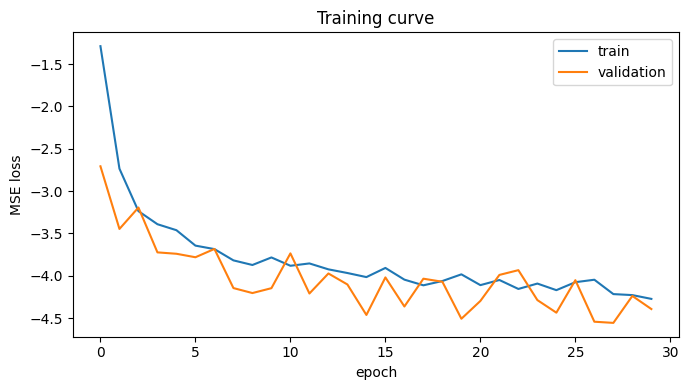

In [6]:
# Source: standalone training loop for the IceCube graph batch pipeline.
num_epochs = 30
train_losses, val_losses = train_graph_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    num_epochs=num_epochs,
    device=device,
    patience=8,
)

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='validation')
plt.xlabel('epoch')
plt.ylabel('NLL loss')
plt.title('Training curve')
plt.legend()
plt.tight_layout()
plt.show()

# Training curve

This plot shows the training and validation loss per epoch. Lower values indicate better fit; use the validation curve to monitor generalization and detect overfitting (when validation loss rises while training loss falls).

RMSE x: 1.2365
RMSE y: 1.6485
MAE x:  0.7916
MAE y:  1.0831
Median radial error: 1.0090


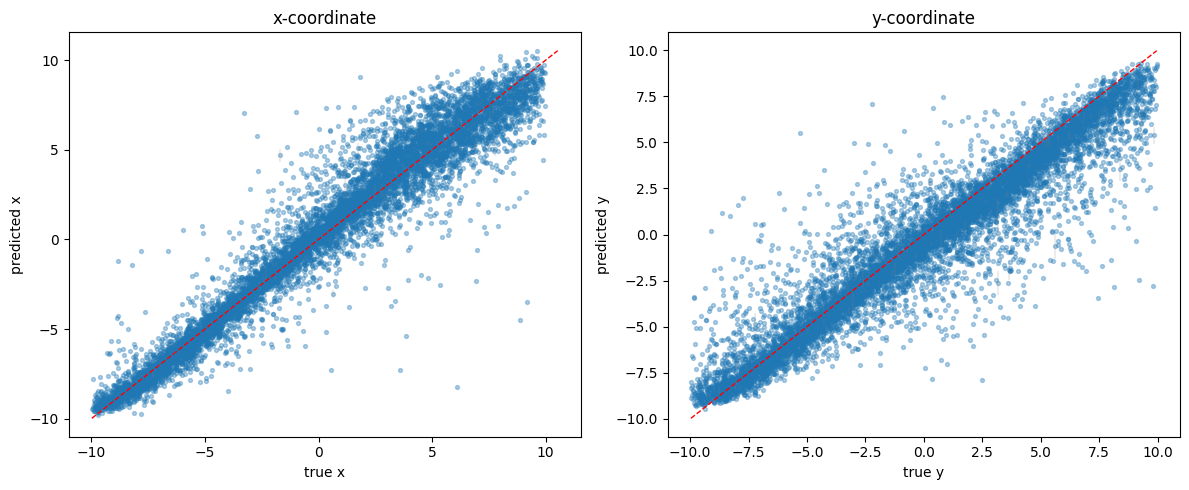

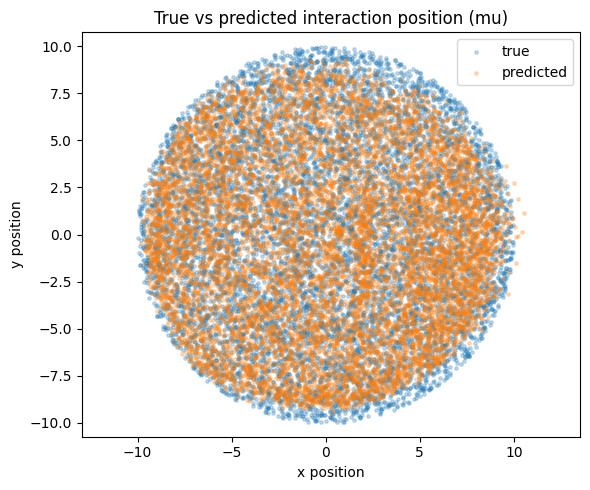

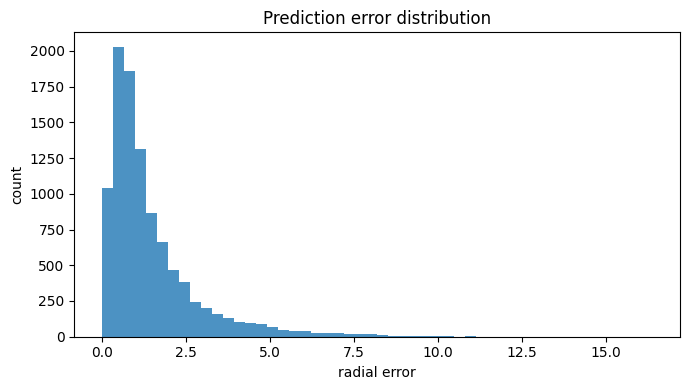

In [7]:
# Source: evaluation & visualization for probabilistic (NLL) model outputs.
pred_combined, target_norm = evaluate_graph_model(model, test_loader, device)

if pred_combined.shape[1] == 4:
    # split mu and log_var
    mu_norm = pred_combined[:, :2]
    log_var_norm = pred_combined[:, 2:]
    std_norm = np.exp(log_var_norm)

    # denormalize means and scale std accordingly
    pred = denormalize(mu_norm, label_ranges)
    scale = (label_ranges[1] - label_ranges[0])
    std = std_norm * scale
else:
    # fallback: deterministic predictions
    pred = denormalize(pred_combined, label_ranges)
    std = np.zeros_like(pred)

target = denormalize(target_norm, label_ranges)

errors = pred - target
rmse_x = float(np.sqrt(np.mean(errors[:, 0] ** 2)))
rmse_y = float(np.sqrt(np.mean(errors[:, 1] ** 2)))
mae_x = float(np.mean(np.abs(errors[:, 0])))
mae_y = float(np.mean(np.abs(errors[:, 1])))
radial_error = np.sqrt(np.sum(errors ** 2, axis=1))
median_radial_error = float(np.median(radial_error))

print(f'RMSE x: {rmse_x:.4f}')
print(f'RMSE y: {rmse_y:.4f}')
print(f'MAE x:  {mae_x:.4f}')
print(f'MAE y:  {mae_y:.4f}')
print(f'Median radial error: {median_radial_error:.4f}')

# Scatter plots with 1-sigma uncertainty shading (density of points may hide error bars)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, axis_name in enumerate(['x', 'y']):
    axes[idx].scatter(target[:, idx], pred[:, idx], s=8, alpha=0.35)
    lower = min(target[:, idx].min(), pred[:, idx].min())
    upper = max(target[:, idx].max(), pred[:, idx].max())
    axes[idx].plot([lower, upper], [lower, upper], 'r--', linewidth=1)
    # show median 1-sigma as dashed lines around predictions for a subset
    if std is not None and std.shape[0] > 0:
        # plot +-1 sigma for a random subset to avoid overplotting
        idxs = np.random.choice(len(pred), size=min(200, len(pred)), replace=False)
        axes[idx].errorbar(target[idxs, idx], pred[idxs, idx], yerr=std[idxs, idx], fmt='none', ecolor='gray', alpha=0.15)
    axes[idx].set_xlabel(f'true {axis_name}')
    axes[idx].set_ylabel(f'predicted {axis_name}')
    axes[idx].set_title(f'{axis_name}-coordinate')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(target[:, 0], target[:, 1], s=6, alpha=0.25, label='true')
plt.scatter(pred[:, 0], pred[:, 1], s=6, alpha=0.25, label='predicted')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('True vs predicted interaction position (mu)')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(radial_error, bins=50, alpha=0.8)
plt.xlabel('radial error')
plt.ylabel('count')
plt.title('Prediction error distribution')
plt.tight_layout()
plt.show()

# Evaluation plots

True vs Predicted (x and y): scatter plots show true coordinate vs predicted coordinate; the red dashed line is the ideal perfect-prediction diagonal. Error bars (gray) show the model's 1σ uncertainty where available.

Spatial overlay: the map shows true positions and predicted positions; close clustering indicates good spatial accuracy.

Radial error histogram: distribution of the prediction distances (radial errors) between true and predicted positions; the median radial error is printed above.